# CONVERSATIONAL CHAT BOT 

In [1]:
from typing import Annotated
from typing_extensions import TypedDict 
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os 
from IPython.display import Image,display


In [2]:
load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGSMITH_PROJECT")

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="qwen/qwen3.6-27b")


In [3]:
# Correct ✅
class State(TypedDict):
    messages: Annotated[list, add_messages]


In [4]:
def chatbot(state:State):
    response=llm.invoke(state["messages"])
    return{"messages":[response]}

In [5]:
grap_builder=StateGraph(State)



In [6]:
grap_builder.add_node("chatbot_node",chatbot)

In [7]:
grap_builder.add_edge(START,"chatbot_node")

grap_builder.add_edge("chatbot_node",END)


In [8]:
bot=grap_builder.compile()

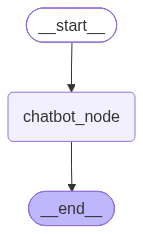

In [9]:
try:
    display(Image(bot.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
# Correctly formatting the input to match your State definition
input_state = {
    "messages": [
        {"role": "user", "content": "Hi, how are u what kind of help u will do ."}
    ]
}

result = bot.invoke(input_state)
print(result["messages"][-1].content)


<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - Greeting: "Hi, how are u"
   - Question: "what kind of help u will do ."
   - Tone: Casual, friendly
   - Intent: Wants to know my capabilities/how I can assist

2.  **Identify Key Components to Address:**
   - Acknowledge greeting & respond politely
   - Clearly explain my capabilities/help areas
   - Keep it concise, friendly, and structured
   - Invite them to share what they need help with

3.  **Determine Core Capabilities (as an AI assistant):**
   - Answer questions (general knowledge, technical, academic, etc.)
   - Writing & editing (emails, essays, stories, code, reports)
   - Problem solving (math, logic, programming, troubleshooting)
   - Learning & explanation (break down complex topics, study help)
   - Productivity (planning, summarizing, organizing, brainstorming)
   - Creative work (ideas, scripts, poetry, design concepts)
   - Language support (translation, grammar, tone adjustment)
   - Note: I sho